<a href="https://colab.research.google.com/github/StellaKahianyu/Bank_Churn_Prediction_ML/blob/main/Bank_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Libraries

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

Loading Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data = pd.read_excel('/content/drive/My Drive/Colab Notebooks/Churn_Modelling.xlsx')
data.head()

Mounted at /content/drive


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
data.shape

(10000, 14)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
data.dtypes

,0
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64


Data Cleaning

In [ ]:
data = data.drop(columns = ['RowNumber','CustomerId','Surname'])
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
##checking missing values
data.isna().any(axis=1).sum()

np.int64(0)

In [ ]:
##checking duplicate values
data.duplicated().sum()

np.int64(0)

Exploratory Data Analysis (EDA)

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


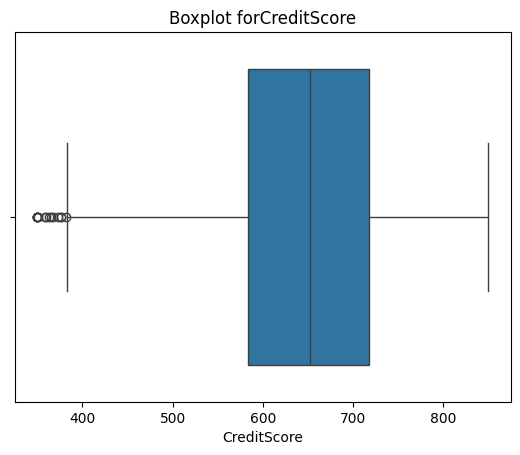

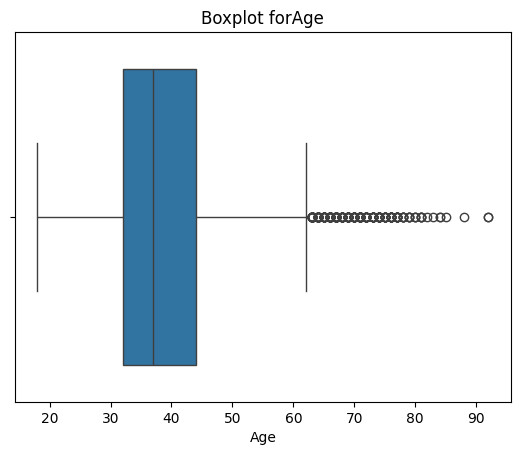

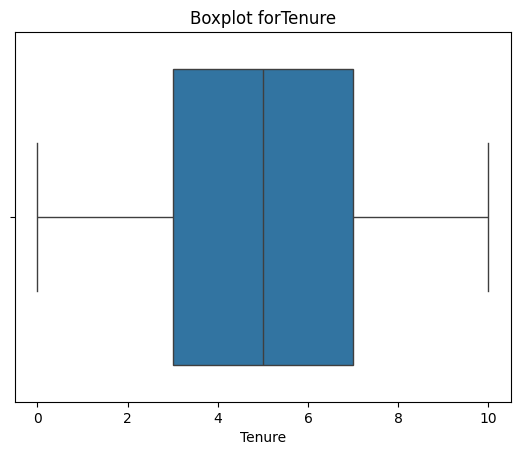

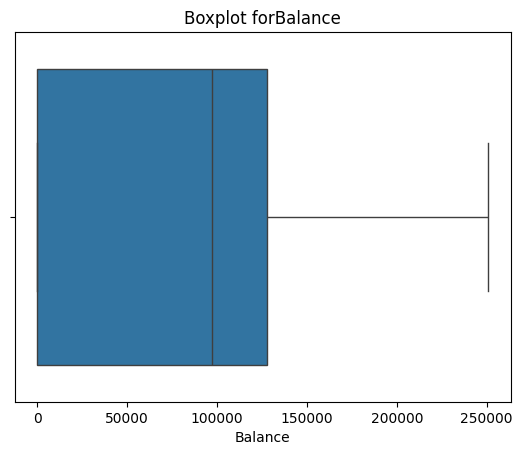

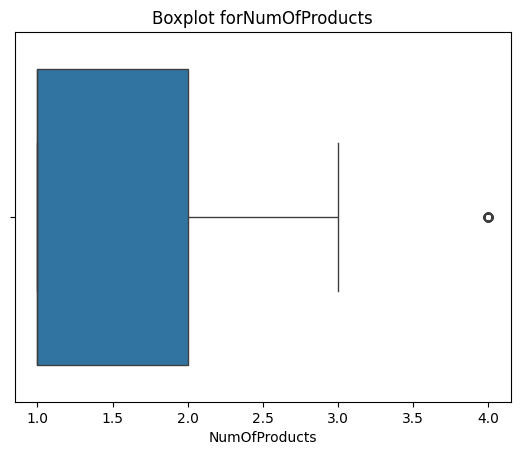

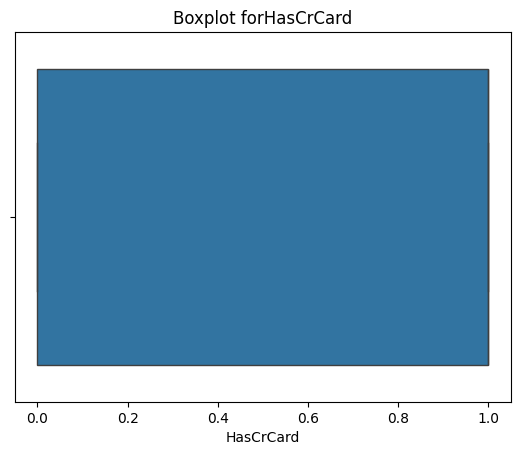

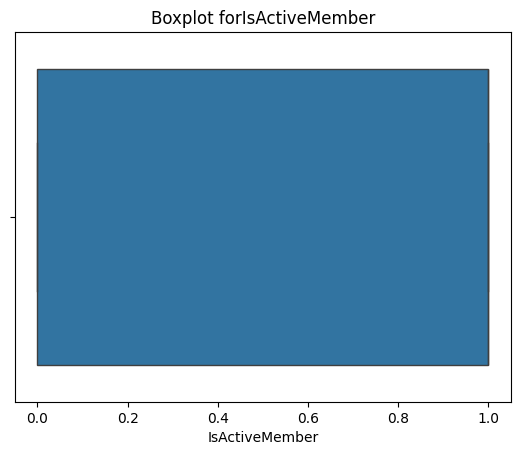

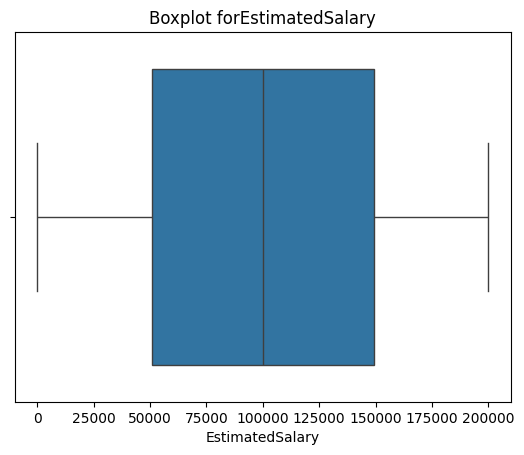

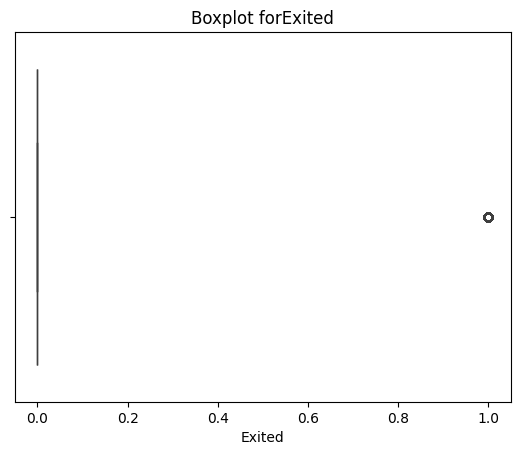

In [ ]:
for col in data.select_dtypes(include = 'number').columns:
    plt.figure()
    sns.boxplot(x = data[col])
    plt.title(f'Boxplot for{col}')
    plt.show()

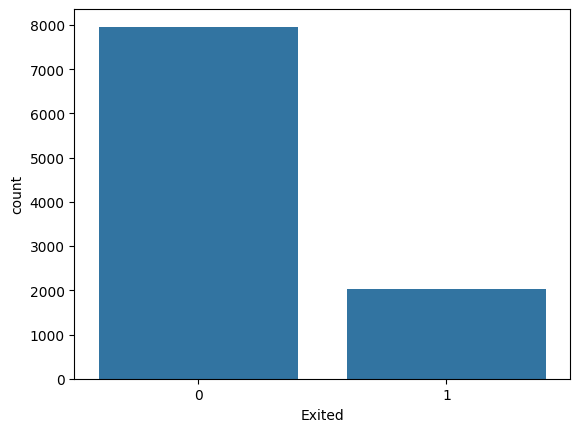

In [ ]:
sns.countplot(x='Exited', data=data)
plt.show()

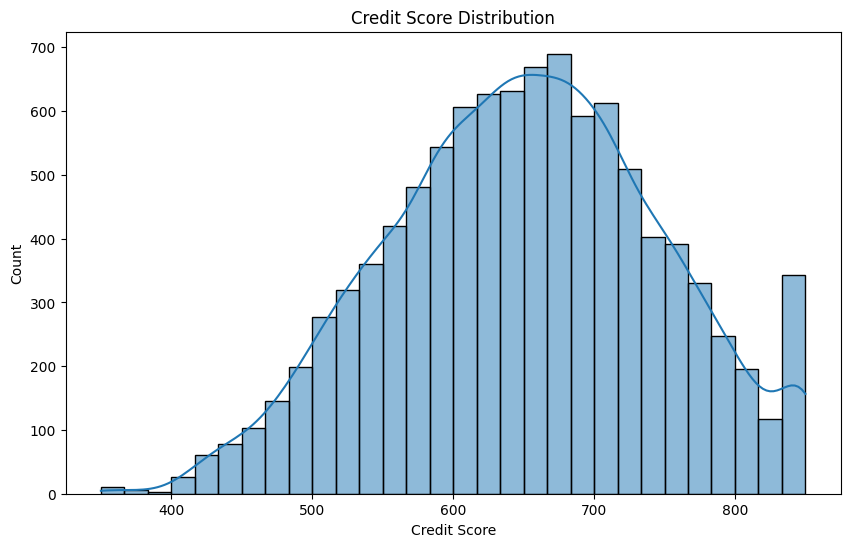

In [ ]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(data["CreditScore"], bins=30, kde=True)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")

plt.show()

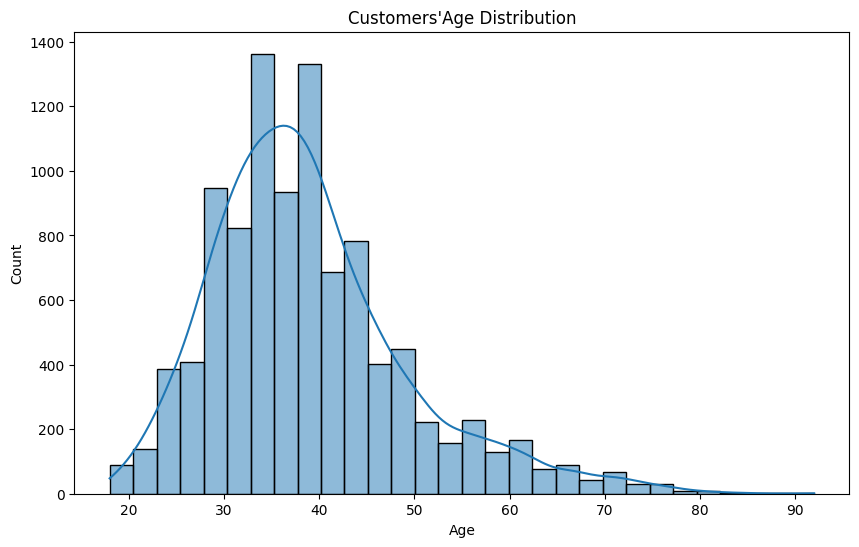

In [ ]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(data["Age"], bins=30, kde=True)

plt.title("Customers'Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

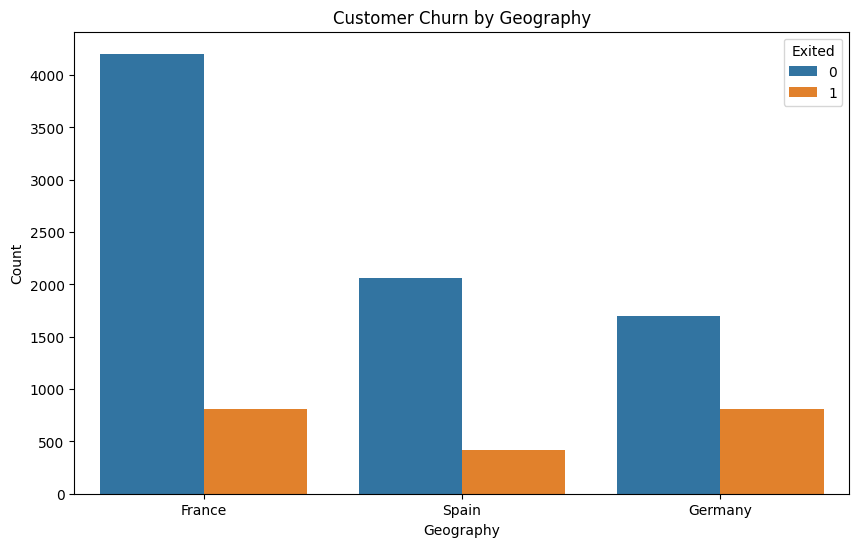

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=data, x="Geography", hue="Exited")

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Count")

plt.show()

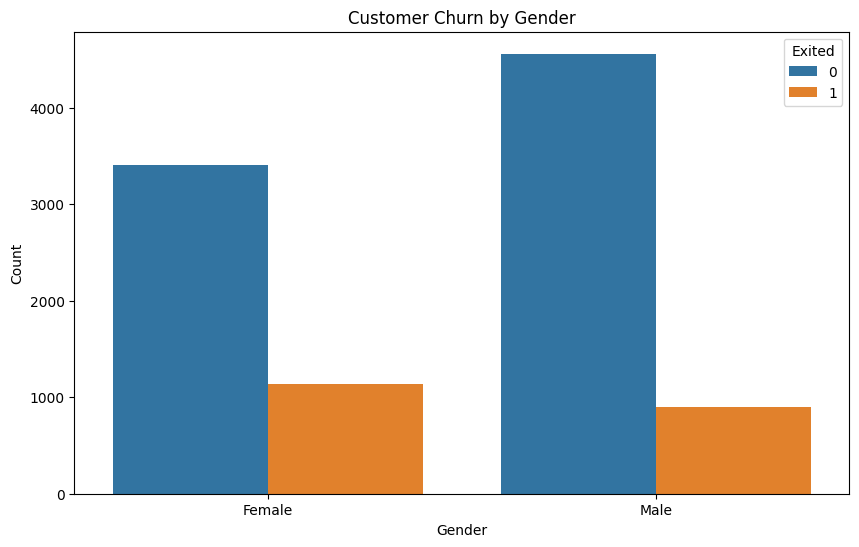

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=data, x="Gender", hue="Exited")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

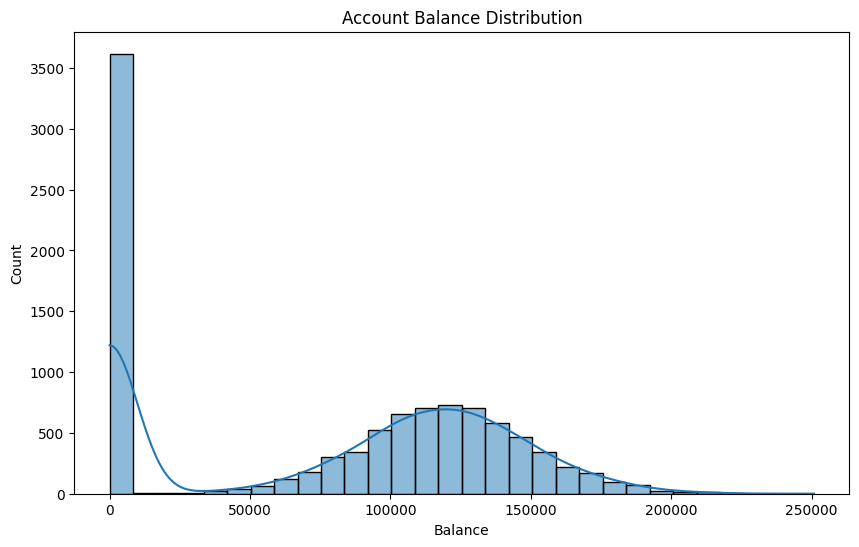

In [ ]:
fig = plt.figure(figsize=(10, 6))
sns.histplot(data["Balance"], bins=30, kde=True)

plt.title("Account Balance Distribution")
plt.xlabel("Balance")
plt.ylabel("Count")

plt.show()

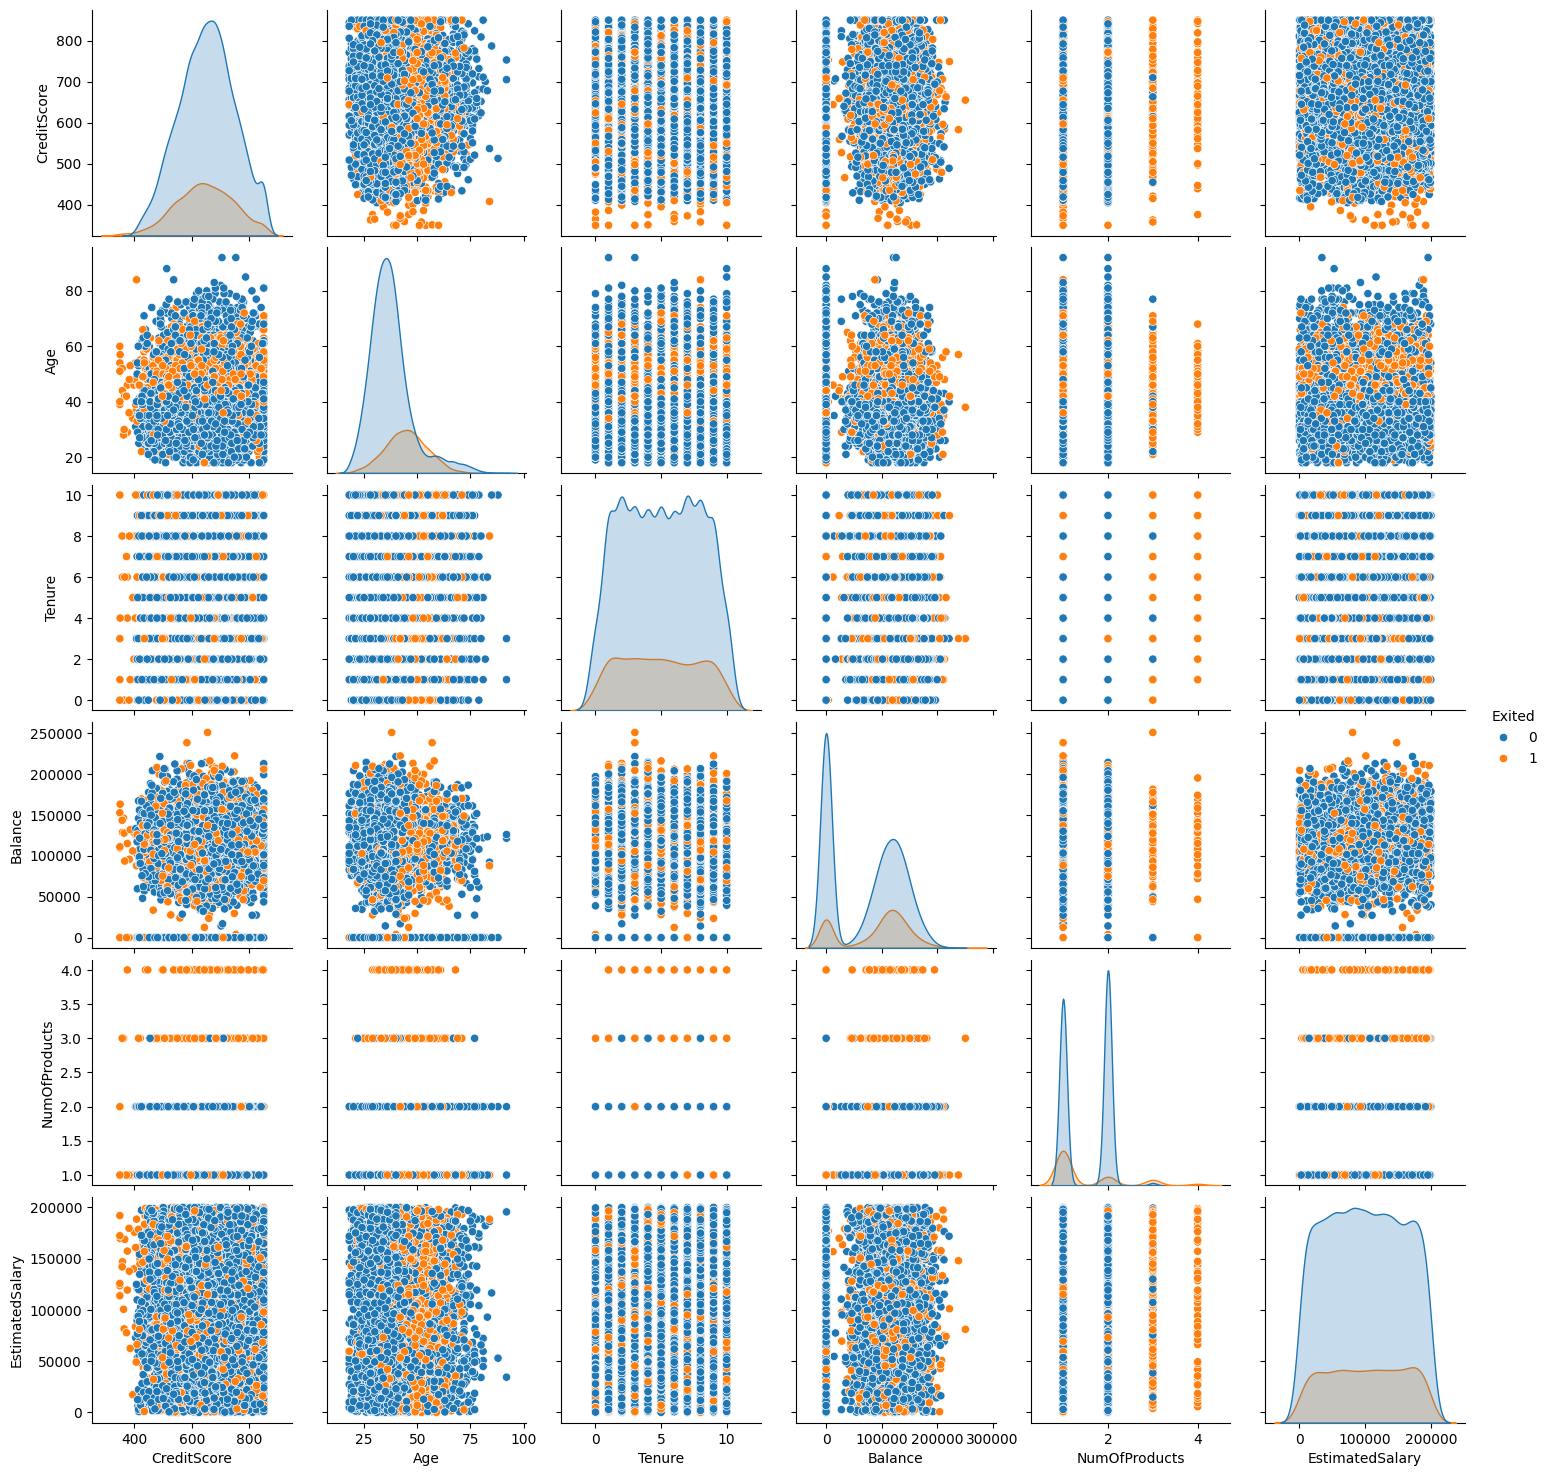

In [ ]:
X=data[[ 'CreditScore', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'EstimatedSalary','Exited']]
y=data['Exited']
sns.pairplot(data=X,hue='Exited')
plt.show()

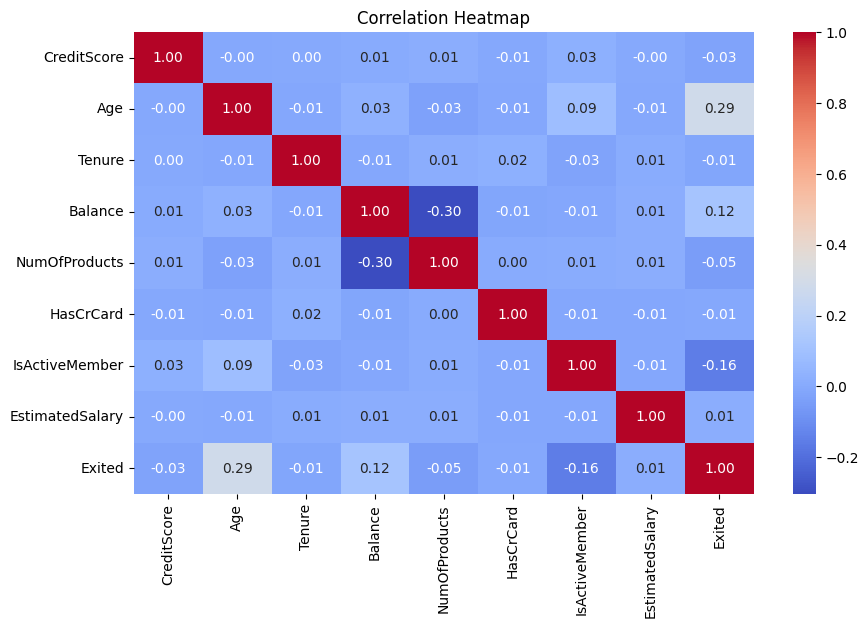

In [ ]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(data.select_dtypes(include="number").corr(), annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.xlabel("")
plt.ylabel("")

plt.show()

# **Data Prepocessing**

In [ ]:
# label encoding
# identify columns that need encoding
#columns_to_encode = ['Var1', 'Var2', 'Var3']
categorical_features = data.select_dtypes(include='object').columns.tolist()
print(categorical_features)

# apply lable encoder
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le   # save encoder for inverse transform

print(data.head())

['Geography', 'Gender']
   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  Exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


In [ ]:
#define features and target
X = data.drop('Exited', axis=1)
y = data['Exited']


In [ ]:
#split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
X_train.shape

(8000, 10)

In [ ]:
y_train.shape

(8000,)

# **Building the Model**

# Logistic Regression

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
logistic_model = LogisticRegression(random_state=42)
logistic_model.fit(X_train, y_train)
predictions = logistic_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
report = classification_report(y_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.14      0.23       407

    accuracy                           0.81      2000
   macro avg       0.70      0.56      0.56      2000
weighted avg       0.77      0.81      0.75      2000



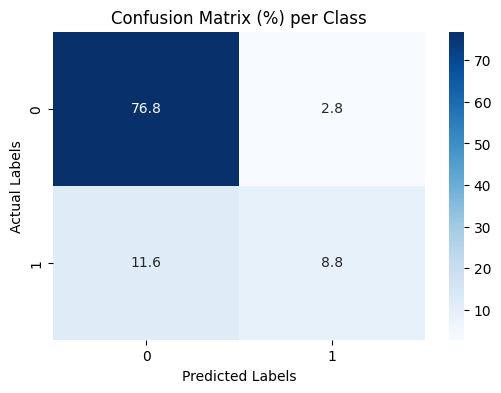

In [ ]:
#cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_percent = cm / cm.sum() * 100
plt.figure(figsize=(6,4))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues')
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix (%) per Class")
plt.show()


# Comparison Models

Accuracy: 0.8560
Confusion Matrix:
 [[1537   56]
 [ 232  175]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91      1593
           1       0.76      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.73      2000
weighted avg       0.85      0.86      0.84      2000



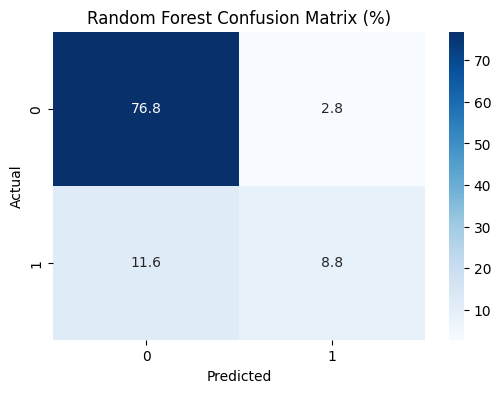

In [ ]:
# Instantiate model (handle imbalance)
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200,        # more trees for stability
    max_depth=None,           # grow until pure
    class_weight='balanced'   # important for churn
)

# Fit model
rf_model.fit(X_train, y_train)

# Predictions
preds = rf_model.predict(X_test)
probs = rf_model.predict_proba(X_test)[:,1]  # churn probability

# Evaluate
accuracy = accuracy_score(y_test, preds)
cm = confusion_matrix(y_test, preds)
report = classification_report(y_test, preds)

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", report)

# Optional: Confusion matrix as heatmap
cm_percent = cm / cm.sum() * 100
plt.figure(figsize=(6,4))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix (%)")
plt.show()